# Deep Learning Module End Assignment

## Objective:
You are required to model the progression of diabetes using the available independent variables. This model will help healthcare professionals understand how different factors influence the progression of diabetes and potentially aid in designing better treatment plans and preventive measures. The model will provide insights into the dynamics of diabetes progression in patients.

In [171]:
# Data Handling and Manipulation
import pandas as pd
from sklearn.datasets import load_diabetes
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Building
import tensorflow as tf
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Model Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Loading and Preprocessing

In [172]:
# 1.1 Load the diabetes dataset
diabetes_sklearn = load_diabetes()

df = pd.DataFrame(data=diabetes_sklearn.data,
                           columns=diabetes_sklearn.feature_names)

df['target'] = diabetes_sklearn.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [173]:
# Show Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [174]:
print("Total No. of Features  : ", df.shape[1])
print("Total No. of Rows      : ", df.shape[0])

Total No. of Features  :  11
Total No. of Rows      :  442


In [175]:
# 1.2 Handling Missing Values
print("\nTotal No. of Missing Values:")
print("---------------------------")
df.isnull().sum()


Total No. of Missing Values:
---------------------------


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [176]:
# Check Duplicate Values
print("Total No. of Duplicate Values: ", df.duplicated().sum())

Total No. of Duplicate Values:  0


In [177]:
X = df.drop('target', axis=1)
y = df['target']

In [178]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [179]:
# 1.3 Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Exploratory Data Analysis (EDA)

In [180]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


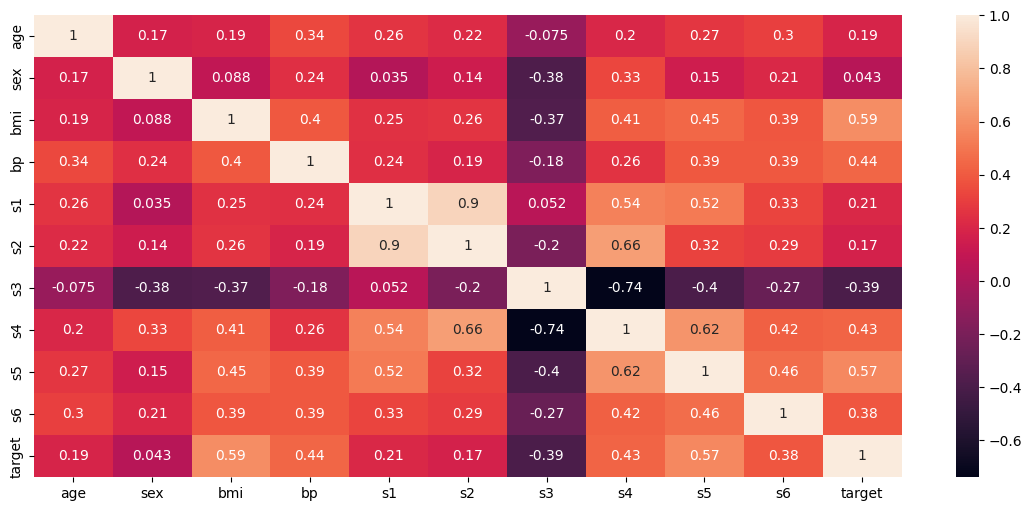

In [181]:
# Correlation Analysis of Target
plt.figure(figsize=(14,6))
df_corr = df.corr()
sns.heatmap(df_corr, annot=True)
plt.show()

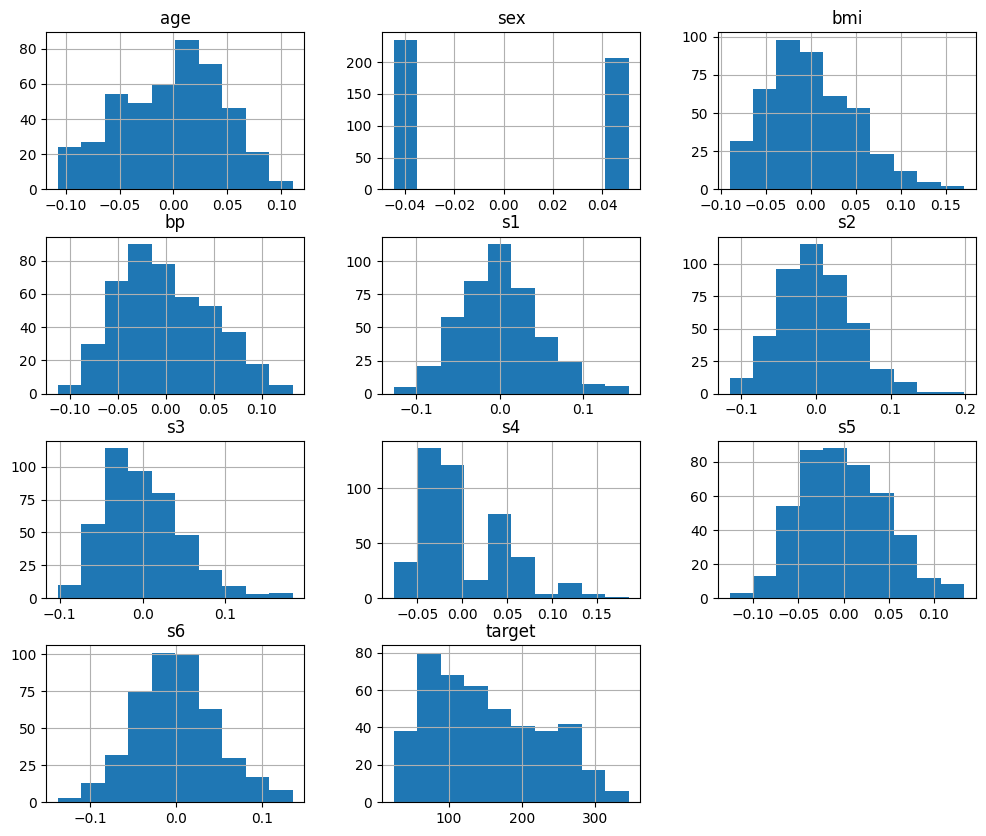

In [182]:
df.hist(figsize=(12,10))
plt.show()

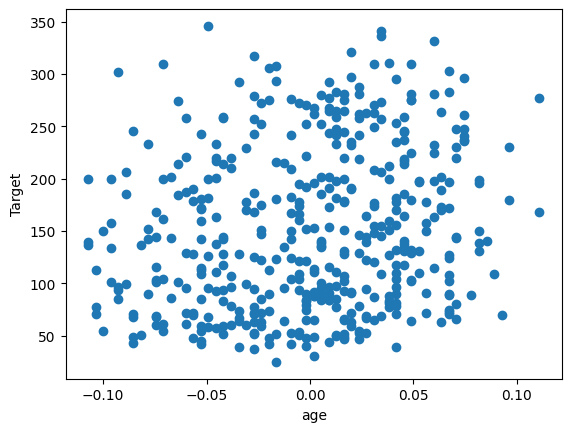

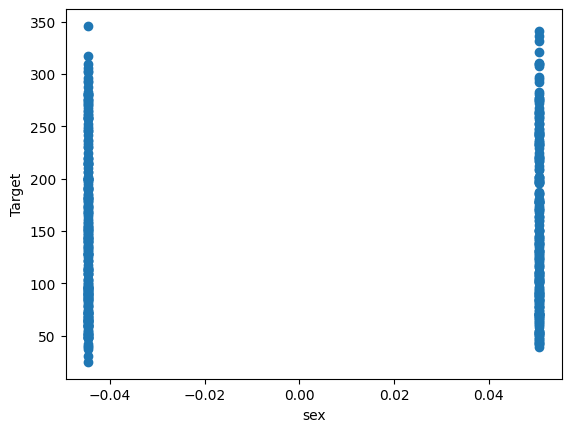

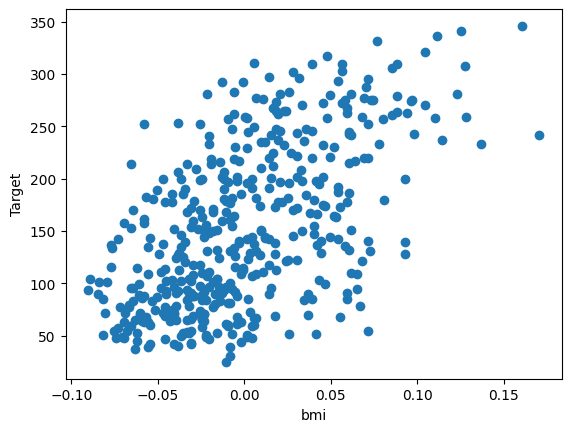

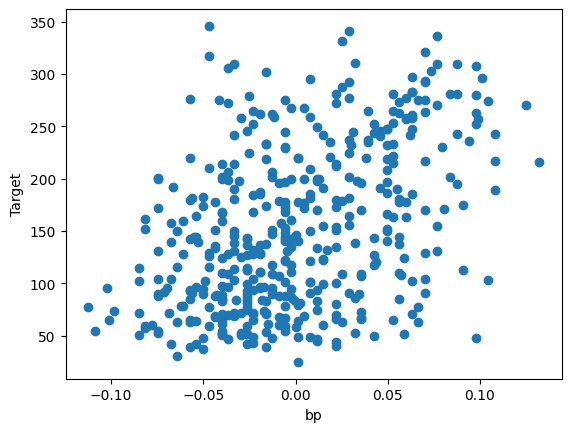

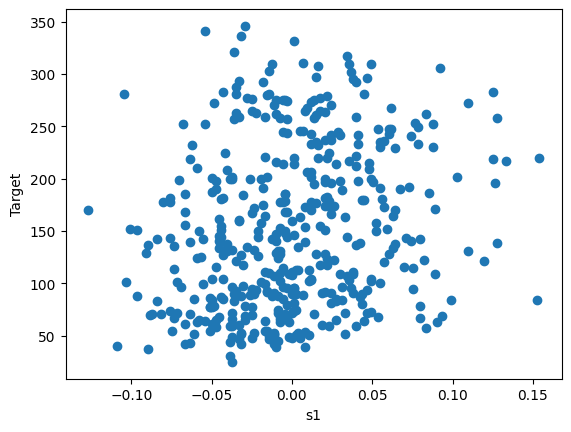

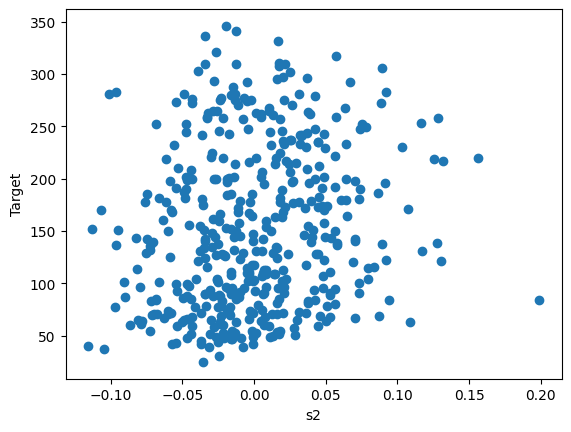

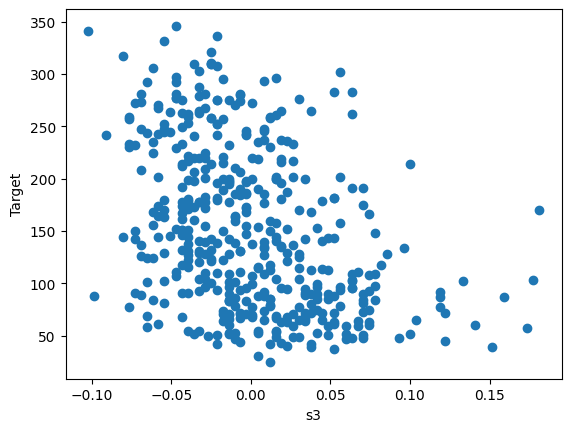

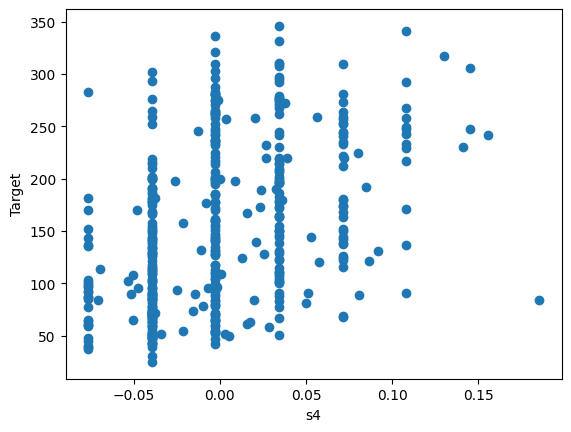

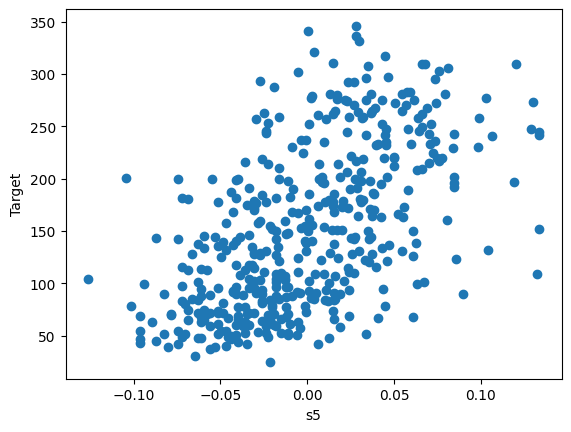

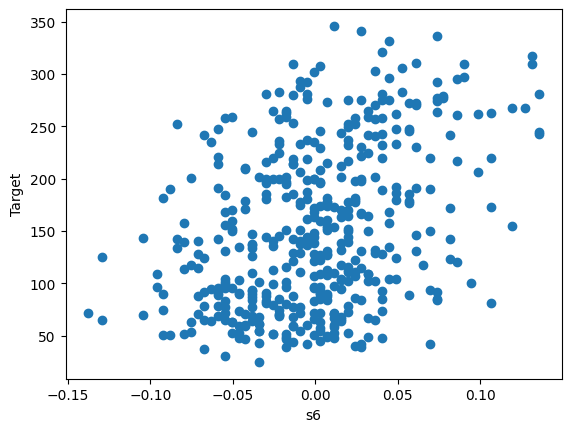

In [183]:
for col in X.columns:
    plt.scatter(df[col], y)
    plt.xlabel(col)
    plt.ylabel('Target')
    plt.show()

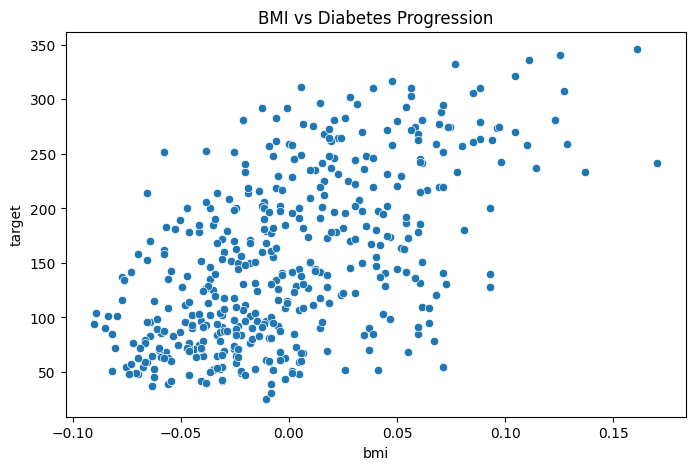

In [184]:
# BMI vs Target (high correlation)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['bmi'], y=df['target'])
plt.title('BMI vs Diabetes Progression')
plt.show()

# 3. Building the ANN Model

In [185]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Training the ANN Model

In [186]:
ann_model = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)

# 5. Evaluating the Model

In [187]:
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
MSE: 2863.21
MAE: 43.06
R2 Score: 0.46


# 6. Improving the Model

In [188]:
model_improved = Sequential([
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [189]:
# Use a specific learning rate for more stability
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_improved.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

In [190]:
# Increased epochs but added Early Stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
    )

history_improved = model_improved.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

In [191]:
# Final Evaluation
y_pred_final = model_improved.predict(X_test_scaled)

improved_mse = mean_squared_error(y_test, y_pred_final)
improved_mae = mean_absolute_error(y_test, y_pred_final)
improved_r2 = r2_score(y_test, y_pred_final)

print(f"MSE: {improved_mse:.2f}")
print(f"MAE: {improved_mae:.2f}")
print(f"R2 Score: {improved_r2:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
MSE: 2917.05
MAE: 42.98
R2 Score: 0.45


## Report of Changes
* Fixed Data Scaling: I moved the scaling process to happen after splitting the data. This ensures the model doesn't "cheat" by seeing the test data statistics during training.

* Adjusted Model Size: I changed the layers from 32 --> 16 neurons to 64 --> 32 neurons. This was an attempt to help the model learn more complex patterns in the diabetes data.

* Added L2 Regularization: I added a penalty (L2) to the first layer. This prevents the model from relying too heavily on any single feature, which helps stop overfitting.

* Implemented Early Stopping: I added a "stop" switch that ends training automatically if the validation loss stops improving. This saves the "best" version of the model instead of just the "last" version.

* Increased Training Time: I set the maximum epochs to 500. This gives the model plenty of time to find the best solution without the risk of overtraining, thanks to Early Stopping.